# Book Review Sentiment Classification using RNN, LSTM & Word2Vec
**Module:** 6CS012 – Artificial Intelligence and Machine Learning  
**Assessment:** Final Portfolio – Part III: Language Tasks  
**Dataset:** Book Review Dataset (12,000 reviews, ratings 1–5, Amazon 1996–2014)  

### Notebook Structure
1. Installations & Imports  
2. Load & Explore Dataset  
3. Text Preprocessing & Cleaning  
4. Visualisation (Word Cloud, Frequency Plot)  
5. Tokenisation & Sequence Padding  
6. Model 1 – Simple RNN with Trainable Embedding  
7. Model 2 – LSTM with Trainable Embedding  
8. Model 3 – LSTM with Pretrained GloVe (Word2Vec) Embeddings  
9. Model Comparison & Evaluation  
10. Error Analysis  
11. Real-Time Prediction GUI (Gradio)  

> ⚡ Run on **Google Colab** with GPU for faster training


## 1. Installations & Imports

In [2]:
# Install required packages (run once)
!pip install wordcloud gradio contractions --quiet
!pip install gensim --quiet

In [3]:
import os, re, time, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer

import contractions
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow.keras.models             import Sequential
from tensorflow.keras.layers             import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks          import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils              import to_categorical

import gensim.downloader as gensim_api

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load & Explore Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Update this path to where your CSV is stored in Drive
CSV_PATH = '/content/drive/MyDrive/AI_sem6/Book_review (1).csv'

df = pd.read_csv(CSV_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df = df.rename(columns={'reviewText': 'review_text'})

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)


Mounted at /content/drive
Shape: (12000, 3)
Columns: ['rating', 'review_text', 'summary']


,rating,review_text,summary
0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!


In [5]:
print("=== Dataset Info ===")
print(df.info())
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Rating distribution:")
print(df['rating'].value_counts().sort_index())


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   rating       12000 non-null  int64 
 1   review_text  12000 non-null  object
 2   summary      11998 non-null  object
dtypes: int64(1), object(2)
memory usage: 281.4+ KB
None

Missing values:
rating         0
review_text    0
summary        2
dtype: int64

Rating distribution:
rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64


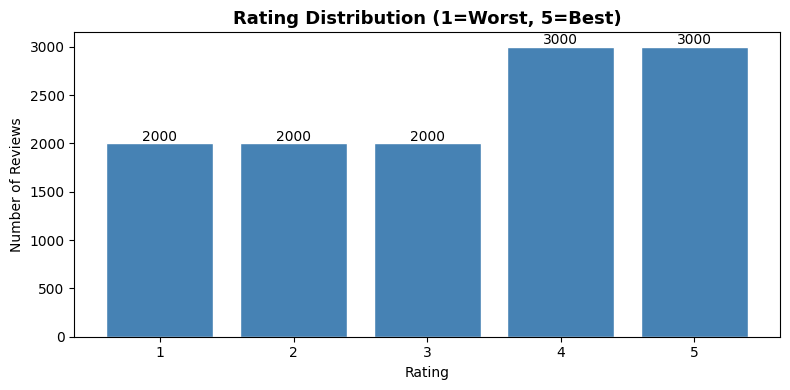

Total reviews : 12000
Rating classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [6]:
# Rating distribution bar chart
plt.figure(figsize=(8, 4))
counts = df['rating'].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
plt.title('Rating Distribution (1=Worst, 5=Best)', fontsize=13, fontweight='bold')
plt.xlabel('Rating'); plt.ylabel('Number of Reviews')
for i, v in enumerate(counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Total reviews : {len(df)}")
print(f"Rating classes: {sorted(df['rating'].unique())}")


## 3. Text Preprocessing & Cleaning

Steps applied:
1. Expand contractions (e.g. "don't" → "do not")
2. Lowercase all text
3. Remove URLs, mentions, hashtags, numbers, punctuation
4. Remove stopwords
5. Lemmatize words to base form


In [7]:
lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ''
    # Expand contractions
    text = contractions.fix(text)
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenise, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_review'] = df['review_text'].apply(clean_text)

# Drop any rows where cleaning produced empty string
df = df[df['clean_review'].str.strip() != ''].reset_index(drop=True)

print(f"Reviews after cleaning: {len(df)}")
print()
print("Before cleaning:", df['review_text'].iloc[1][:150])
print()
print("After cleaning :", df['clean_review'].iloc[1][:150])


Reviews after cleaning: 12000

Before cleaning: When I read the description for this book, I couldn't wait to read it. Once I downloaded it to my Kindle, I found it extremely hard to keep reading it

After cleaning : read description book could wait read downloaded kindle found extremely hard keep reading honest stopped reading halfway book began slow remained slow


## 4. Data Visualisation

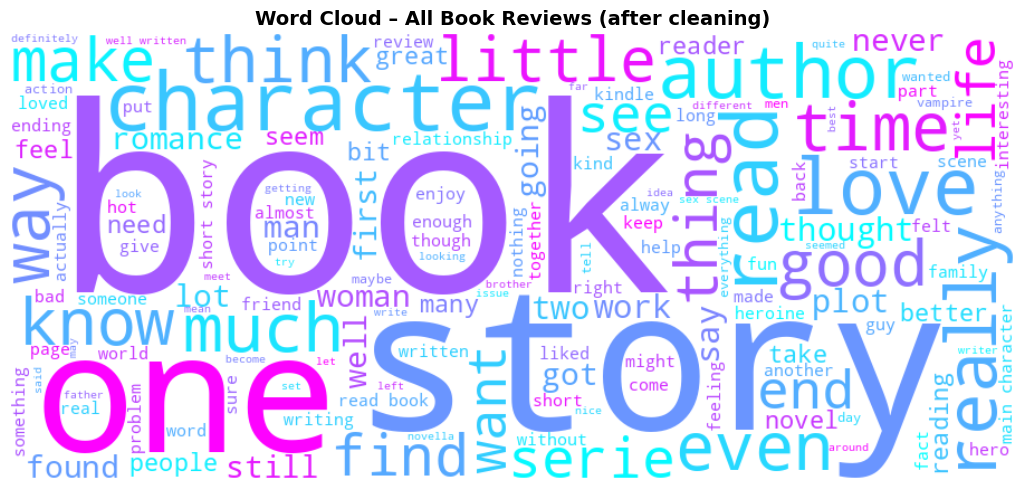

In [8]:
# Word Cloud – all reviews
all_text = ' '.join(df['clean_review'].values)

wc = WordCloud(width=900, height=400, background_color='white',
               colormap='cool', max_words=150).generate(all_text)

plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – All Book Reviews (after cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


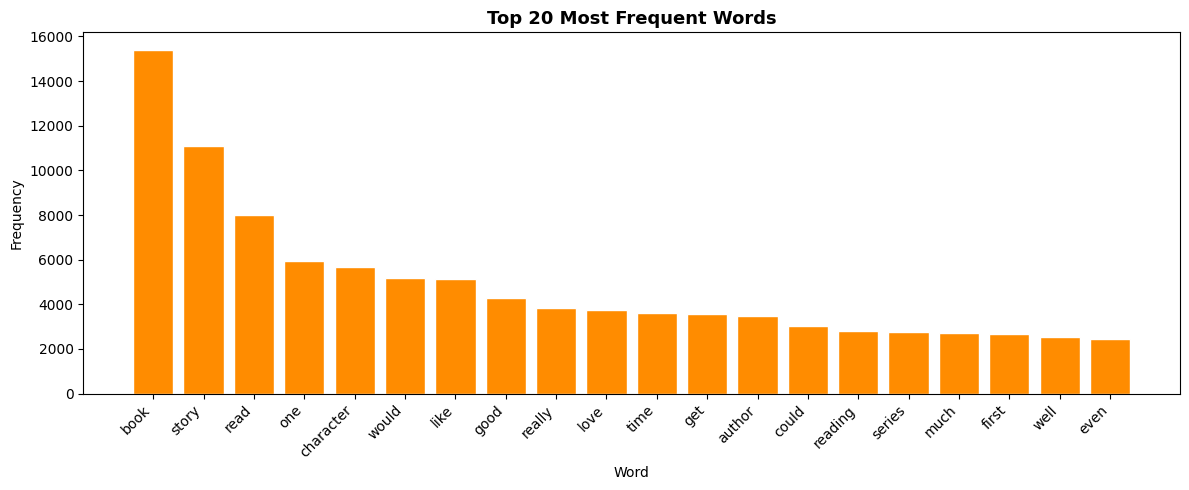

In [9]:
# Top 20 most frequent words
word_freq = Counter(' '.join(df['clean_review']).split()).most_common(20)
words, freqs = zip(*word_freq)

plt.figure(figsize=(12, 5))
plt.bar(words, freqs, color='darkorange', edgecolor='white')
plt.title('Top 20 Most Frequent Words', fontsize=13, fontweight='bold')
plt.xlabel('Word'); plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


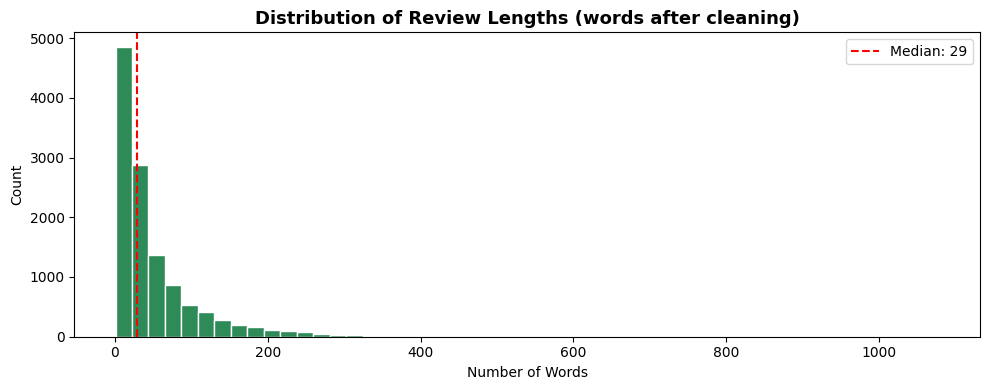

Mean length  : 52.5 words
Median length: 29 words
90th percentile: 125 words


In [10]:
# Review length distribution
df['review_len'] = df['clean_review'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
plt.hist(df['review_len'], bins=50, color='seagreen', edgecolor='white')
plt.title('Distribution of Review Lengths (words after cleaning)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Words'); plt.ylabel('Count')
plt.axvline(df['review_len'].median(), color='red', linestyle='--', label=f"Median: {df['review_len'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean length  : {df['review_len'].mean():.1f} words")
print(f"Median length: {df['review_len'].median():.0f} words")
print(f"90th percentile: {df['review_len'].quantile(0.90):.0f} words")


## 5. Tokenisation, Padding & Label Encoding

- Labels: ratings 1–5 → classes 0–4 (zero-indexed for Keras)
- Train/Val/Test split: 70% / 15% / 15%
- Padding length: 90th percentile of review lengths (avoids excessively long sequences)


In [11]:
# Label encoding: rating 1-5 → 0-4
df['label'] = df['rating'] - 1
NUM_CLASSES  = df['label'].nunique()
print(f"Number of classes: {NUM_CLASSES}")

# Train / val / test split  70 / 15 / 15
X = df['clean_review'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train   : {len(X_train)}")
print(f"Val     : {len(X_val)}")
print(f"Test    : {len(X_test)}")


Number of classes: 5
Train   : 8400
Val     : 1800
Test    : 1800


In [12]:
# Tokenisation
MAX_VOCAB = 20000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
VOCAB_SIZE  = min(MAX_VOCAB, len(word_index) + 1)
print(f"Vocabulary size (capped): {VOCAB_SIZE}")

# Percentile-based padding length
MAX_LEN = int(np.percentile([len(t.split()) for t in X_train], 90))
print(f"Padding length (90th percentile): {MAX_LEN}")

def encode_pad(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_pad = encode_pad(X_train)
X_val_pad   = encode_pad(X_val)
X_test_pad  = encode_pad(X_test)

# One-hot encode labels
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")


Vocabulary size (capped): 20000
Padding length (90th percentile): 126
X_train_pad shape: (8400, 126)
y_train_cat shape: (8400, 5)


## Shared Helper Functions

In [13]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{title} – Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{title} – Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def evaluate_model(model, X, y_true_int, name):
    y_prob = model.predict(X, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc  = accuracy_score(y_true_int, y_pred)
    prec = precision_score(y_true_int, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true_int, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true_int, y_pred,        average='weighted', zero_division=0)

    print('=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print('=' * 55)
    print()
    print(classification_report(y_true_int, y_pred,
          target_names=[f'Rating {i+1}' for i in range(NUM_CLASSES)],
          zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_true_int, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'R{i+1}' for i in range(NUM_CLASSES)],
                yticklabels=[f'R{i+1}' for i in range(NUM_CLASSES)])
    plt.title(f'{name} – Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

    return {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=2, min_lr=1e-7, verbose=1)
    ]

all_results  = []
all_times    = {}


## 6. Model 1 – Simple RNN with Trainable Embedding

**Architecture rationale:**  
SimpleRNN processes the sequence token-by-token, maintaining a hidden state. The trainable Embedding layer learns word representations directly from the training data.


In [14]:
EMBED_DIM = 64

rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, name='rnn_embedding'),
    SimpleRNN(64, return_sequences=False, name='simple_rnn'),
    Dropout(0.40),
    Dense(64, activation='relu'),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation='softmax')
], name='Simple_RNN')

rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
rnn_model.summary()


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_embedding (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
t0 = time.time()

history_rnn = rnn_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)

rnn_time = time.time() - t0
all_times['Simple RNN'] = round(rnn_time, 1)
print(f"\nTraining time: {rnn_time:.1f}s ({rnn_time/60:.1f} min)")


Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.2452 - loss: 1.6020 - val_accuracy: 0.2694 - val_loss: 1.5904 - learning_rate: 0.0010
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2544 - loss: 1.5865 - val_accuracy: 0.2578 - val_loss: 1.5915 - learning_rate: 0.0010
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2787 - loss: 1.5711 - val_accuracy: 0.2428 - val_loss: 1.5895 - learning_rate: 0.0010
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2980 - loss: 1.5502 - val_accuracy: 0.2539 - val_loss: 1.5906 - learning_rate: 0.0010
Epoch 5/15
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3200 - loss: 1.5102
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3224 - loss: 1.5065 - val_accuracy: 0.2567 - val_loss: 1.6116 - learning_rate: 0.0010
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3310 - loss: 1.

plot_history(history_rnn, 'Model 1 – Simple RNN')
result_rnn = evaluate_model(rnn_model, X_test_pad, y_test, 'Simple RNN')
all_results.append(result_rnn)


## 7. Model 2 – LSTM with Trainable Embedding

**Architecture rationale:**  
LSTM introduces gating mechanisms (input, forget, output) which help retain long-range dependencies in text and reduce the vanishing gradient problem compared to SimpleRNN.


In [16]:
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, name='lstm_embedding'),
    LSTM(128, return_sequences=True,  name='lstm_layer_1'),
    Dropout(0.35),
    LSTM(64,  return_sequences=False, name='lstm_layer_2'),
    Dropout(0.35),
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_Trainable_Embedding')

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()


Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_embedding (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_1 (LSTM)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
t0 = time.time()

history_lstm = lstm_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)

lstm_time = time.time() - t0
all_times['LSTM (Trainable Embed)'] = round(lstm_time, 1)
print(f"\nTraining time: {lstm_time:.1f}s ({lstm_time/60:.1f} min)")


Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.2555 - loss: 1.5941 - val_accuracy: 0.2500 - val_loss: 1.5937 - learning_rate: 0.0010
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2594 - loss: 1.5892 - val_accuracy: 0.2500 - val_loss: 1.5920 - learning_rate: 0.0010
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2585 - loss: 1.5793 - val_accuracy: 0.2500 - val_loss: 1.5846 - learning_rate: 0.0010
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2802 - loss: 1.5401 - val_accuracy: 0.2550 - val_loss: 1.6000 - learning_rate: 0.0010
Epoch 5/15
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2959 - loss: 1.4944
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3063 - loss: 1.4857 - val_accuracy: 0.2494 - val_loss: 1.6914 - learning_rate: 0.0010
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3213 - loss: 1.

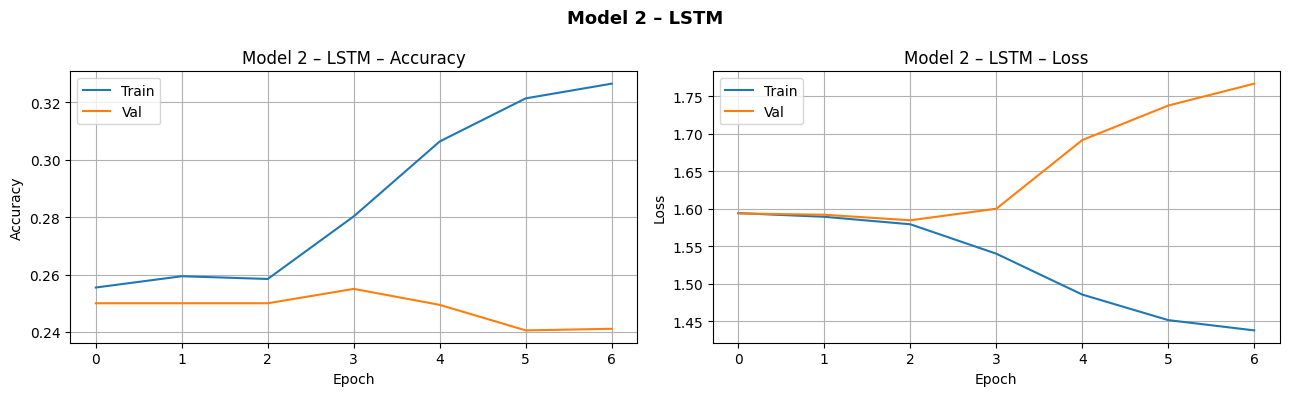

  LSTM (Trainable Embed)
  Accuracy : 0.2506
  Precision: 0.3125
  Recall   : 0.2506
  F1-Score : 0.1012

              precision    recall  f1-score   support

    Rating 1       0.00      0.00      0.00       300
    Rating 2       0.00      0.00      0.00       300
    Rating 3       0.00      0.00      0.00       300
    Rating 4       0.25      1.00      0.40       450
    Rating 5       1.00      0.00      0.00       450

    accuracy                           0.25      1800
   macro avg       0.25      0.20      0.08      1800
weighted avg       0.31      0.25      0.10      1800



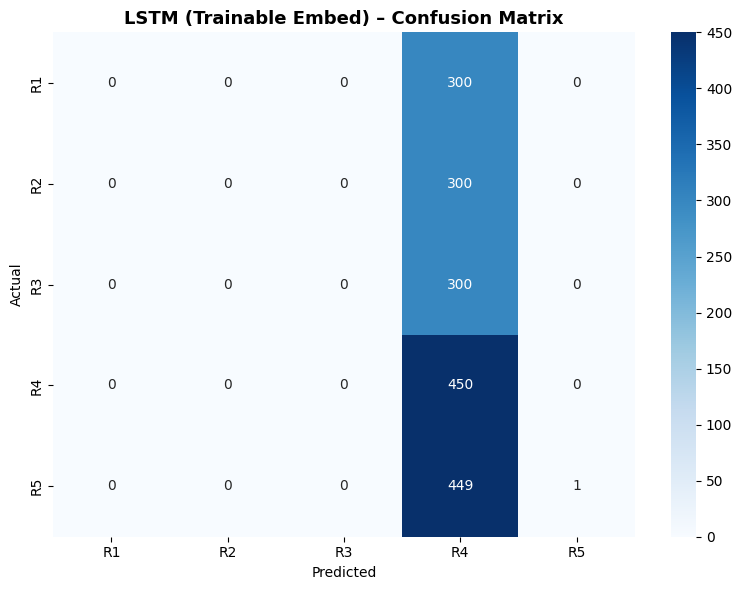

In [18]:
plot_history(history_lstm, 'Model 2 – LSTM')
result_lstm = evaluate_model(lstm_model, X_test_pad, y_test, 'LSTM (Trainable Embed)')
all_results.append(result_lstm)


## 8. Model 3 – LSTM with Pretrained GloVe Embeddings

**Why GloVe?**  
GloVe (Global Vectors) is trained on billions of tokens from Wikipedia and news articles. Using these pretrained embeddings gives the model a richer starting vocabulary representation, especially useful for book review language.

**Model used:** `glove-wiki-gigaword-100` (100-dimensional)


In [19]:
# Load pretrained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings ...")
glove_model  = gensim_api.load('glove-wiki-gigaword-100')
GLOVE_DIM    = 100
print("GloVe loaded. Vocabulary size:", len(glove_model))


Loading GloVe embeddings ...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded. Vocabulary size: 400000


In [21]:
# Build embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found, not_found = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / (found + not_found) * 100
print(f"Words found in GloVe  : {found}")
print(f"Words NOT found        : {not_found}")
print(f"Embedding coverage     : {coverage:.1f}%")
print(f"Embedding matrix shape : {embedding_matrix.shape}")


Words found in GloVe  : 14868
Words NOT found        : 5131
Embedding coverage     : 74.3%
Embedding matrix shape : (20000, 100)


In [22]:
glove_lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=GLOVE_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False,           # Freeze pretrained weights
              name='glove_embedding'),
    LSTM(128, return_sequences=True,  name='glove_lstm_1'),
    Dropout(0.35),
    LSTM(64,  return_sequences=False, name='glove_lstm_2'),
    Dropout(0.35),
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_GloVe_Embedding')

glove_lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
glove_lstm_model.summary()


Model: "LSTM_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_lstm_1 (LSTM)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_lstm_2 (LSTM)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [23]:
t0 = time.time()

history_glove = glove_lstm_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)

glove_time = time.time() - t0
all_times['LSTM (GloVe)'] = round(glove_time, 1)
print(f"\nTraining time: {glove_time:.1f}s ({glove_time/60:.1f} min)")


Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.2563 - loss: 1.5946 - val_accuracy: 0.2500 - val_loss: 1.5895 - learning_rate: 0.0010
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.2599 - loss: 1.5891 - val_accuracy: 0.2578 - val_loss: 1.5875 - learning_rate: 0.0010
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2618 - loss: 1.5872 - val_accuracy: 0.2606 - val_loss: 1.5884 - learning_rate: 0.0010
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2570 - loss: 1.5901 - val_accuracy: 0.2589 - val_loss: 1.5863 - learning_rate: 0.0010
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2599 - loss: 1.5780 - val_accuracy: 0.2500 - val_loss: 1.6114 - learning_rate: 0.0010
Epoch 6/15
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2606 - loss: 1.6003
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.2587 - loss: 1.5

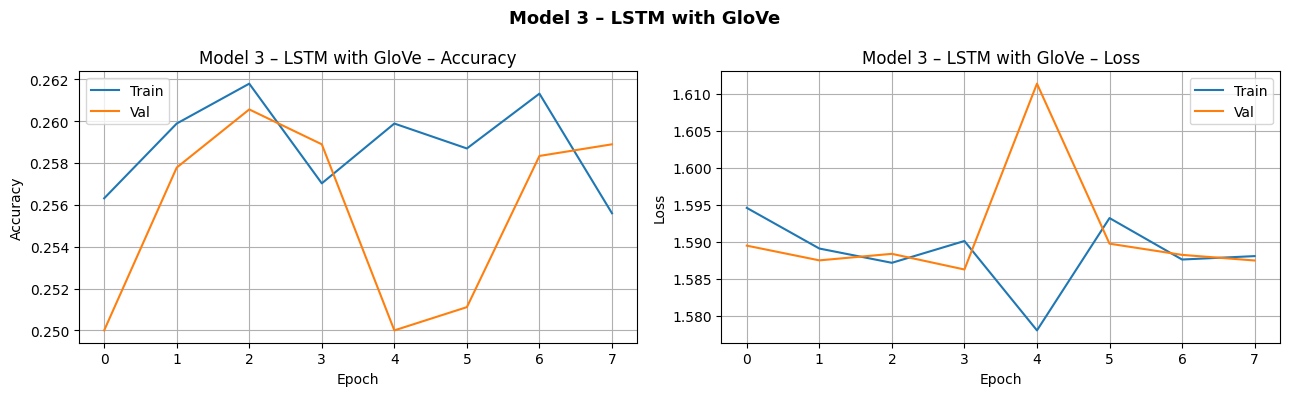

  LSTM (GloVe)
  Accuracy : 0.2511
  Precision: 0.1255
  Recall   : 0.2511
  F1-Score : 0.1402

              precision    recall  f1-score   support

    Rating 1       0.00      0.00      0.00       300
    Rating 2       0.00      0.00      0.00       300
    Rating 3       0.00      0.00      0.00       300
    Rating 4       0.25      0.13      0.17       450
    Rating 5       0.25      0.88      0.39       450

    accuracy                           0.25      1800
   macro avg       0.10      0.20      0.11      1800
weighted avg       0.13      0.25      0.14      1800



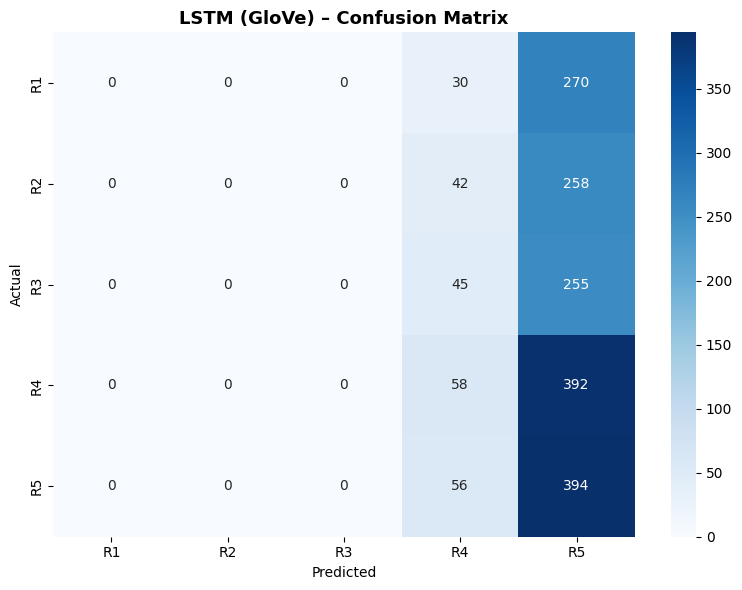

In [24]:
plot_history(history_glove, 'Model 3 – LSTM with GloVe')
result_glove = evaluate_model(glove_lstm_model, X_test_pad, y_test, 'LSTM (GloVe)')
all_results.append(result_glove)


## 9. Model Comparison

,model,accuracy,precision,recall,f1,training_time_s
0,LSTM (GloVe),0.251111,0.125549,0.251111,0.140157,24.7
1,LSTM (Trainable Embed),0.250556,0.312535,0.250556,0.101153,26.5


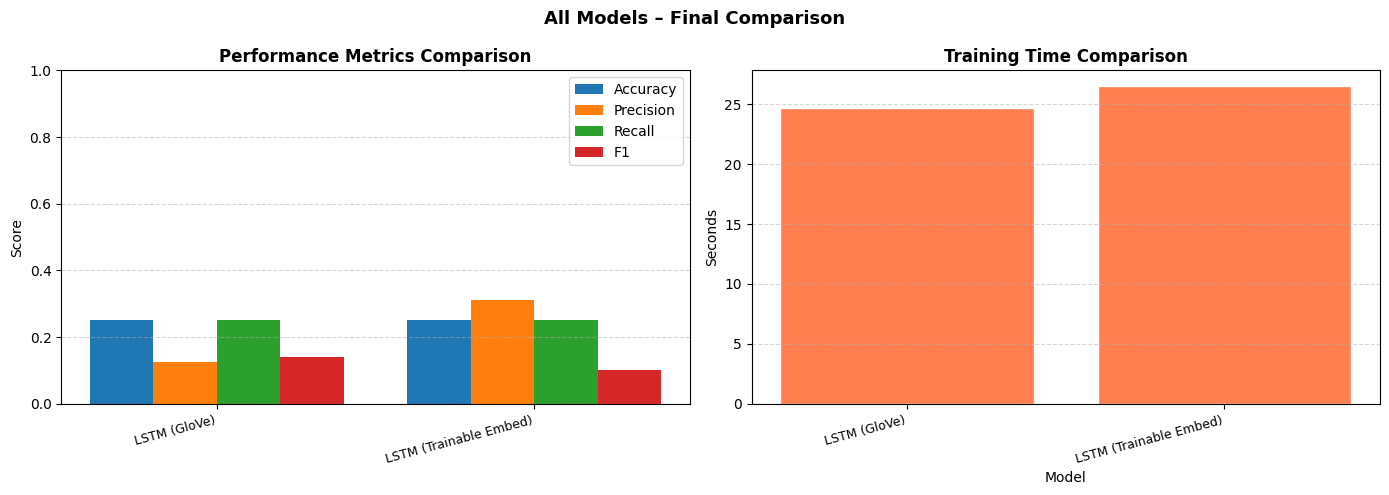

In [25]:
results_df = pd.DataFrame(all_results)
results_df['training_time_s'] = results_df['model'].map(all_times)
results_df = results_df.sort_values('accuracy', ascending=False).reset_index(drop=True)
display(results_df)

metrics = ['accuracy', 'precision', 'recall', 'f1']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x   = np.arange(len(results_df))
w   = 0.20
for i, m in enumerate(metrics):
    axes[0].bar(x + i*w, results_df[m], width=w, label=m.capitalize())
axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels(results_df['model'], rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Score')
axes[0].set_title('Performance Metrics Comparison', fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].bar(results_df['model'], results_df['training_time_s'], color='coral', edgecolor='white')
axes[1].set_title('Training Time Comparison', fontweight='bold')
axes[1].set_xlabel('Model'); axes[1].set_ylabel('Seconds')
axes[1].set_xticklabels(results_df['model'], rotation=15, ha='right', fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('All Models – Final Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


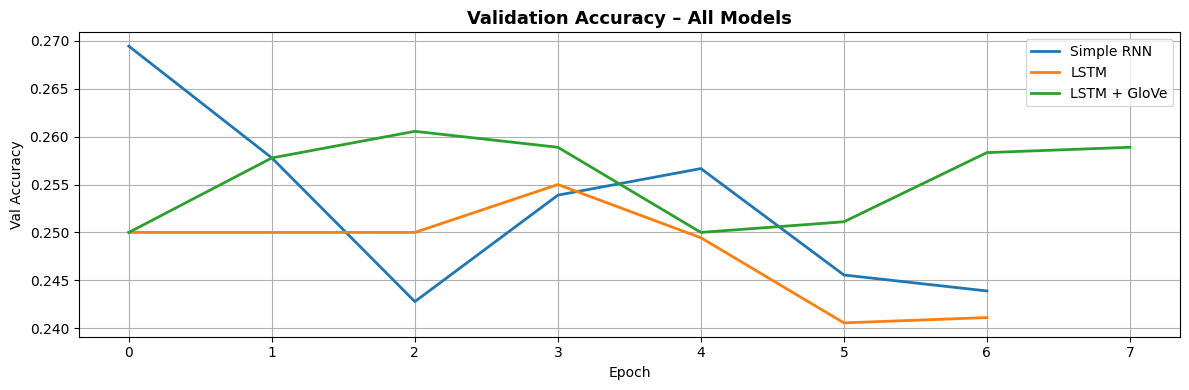

In [26]:
# Convergence comparison
plt.figure(figsize=(12, 4))
plt.plot(history_rnn.history['val_accuracy'],   label='Simple RNN',    linewidth=2)
plt.plot(history_lstm.history['val_accuracy'],  label='LSTM',          linewidth=2)
plt.plot(history_glove.history['val_accuracy'], label='LSTM + GloVe',  linewidth=2)
plt.title('Validation Accuracy – All Models', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()


## 10. Error Analysis

Examining misclassified samples helps us understand where and why the models fail.


In [27]:
# Use best model for error analysis
best_model = glove_lstm_model   # update if another scored higher

y_prob_test = best_model.predict(X_test_pad, verbose=0)
y_pred_test = np.argmax(y_prob_test, axis=1)

# Find misclassified indices
wrong_idx = np.where(y_pred_test != y_test)[0]
print(f"Total test samples     : {len(y_test)}")
print(f"Misclassified          : {len(wrong_idx)}")
print(f"Error rate             : {len(wrong_idx)/len(y_test)*100:.1f}%")
print()

# Show 3 misclassified examples
print("=== 3 Misclassified Examples ===")
for i, idx in enumerate(wrong_idx[:3]):
    print(f"\nExample {i+1}:")
    print(f"  Original review  : {X_test[idx][:120]}...")
    print(f"  True rating      : {y_test[idx] + 1}")
    print(f"  Predicted rating : {y_pred_test[idx] + 1}")
    print(f"  Confidence       : {y_prob_test[idx][y_pred_test[idx]]:.2f}")


Total test samples     : 1800
Misclassified          : 1348
Error rate             : 74.9%

=== 3 Misclassified Examples ===

Example 1:
  Original review  : well usual menage book callie befriended family best friend twist happen possess magical powersthere series death woman ...
  True rating      : 3
  Predicted rating : 5
  Confidence       : 0.24

Example 2:
  Original review  : subscribed new yorker kindle generation became available love getting new issue sunday night central time eastern time w...
  True rating      : 5
  Predicted rating : 4
  Confidence       : 0.28

Example 3:
  Original review  : vengeance scudiere one two book got scudieres publisher review read resonance first really enjoyed saved vengeance last ...
  True rating      : 5
  Predicted rating : 4
  Confidence       : 0.29


In [28]:
# Error type breakdown – which ratings get confused most
error_df = pd.DataFrame({
    'true': y_test[wrong_idx] + 1,
    'pred': y_pred_test[wrong_idx] + 1
})
error_counts = error_df.groupby(['true','pred']).size().reset_index(name='count')
error_counts = error_counts.sort_values('count', ascending=False).head(10)

print("Most common misclassification pairs (True → Predicted):")
print(error_counts.to_string(index=False))
print()
print("=== Possible Reasons for Errors ===")
print("1. Ratings 3-4 are subjective and linguistically similar (mixed sentiment).")
print("2. Sarcasm or irony is difficult for RNN/LSTM to detect.")
print("3. Short reviews lack enough context for the model to decide.")
print()
print("=== Suggested Improvements ===")
print("- Use Transformer-based models (BERT) for better context understanding.")
print("- Map ratings 1-2 → Negative, 3 → Neutral, 4-5 → Positive (3-class problem).")
print("- Increase training data and apply stronger augmentation.")


Most common misclassification pairs (True → Predicted):
 true  pred  count
    4     5    392
    1     5    270
    2     5    258
    3     5    255
    5     4     56
    3     4     45
    2     4     42
    1     4     30

=== Possible Reasons for Errors ===
1. Ratings 3-4 are subjective and linguistically similar (mixed sentiment).
2. Sarcasm or irony is difficult for RNN/LSTM to detect.
3. Short reviews lack enough context for the model to decide.

=== Suggested Improvements ===
- Use Transformer-based models (BERT) for better context understanding.
- Map ratings 1-2 → Negative, 3 → Neutral, 4-5 → Positive (3-class problem).
- Increase training data and apply stronger augmentation.


## 11. Real-Time Prediction GUI (Gradio)

A simple web interface where you can type a book review and get a predicted star rating instantly.


In [29]:
import gradio as gr

def predict_rating(review_text):
    if not review_text.strip():
        return "Please enter a review."
    cleaned  = clean_text(review_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')
    probs    = best_model.predict(padded, verbose=0)[0]
    pred_cls = int(np.argmax(probs))
    stars    = '⭐' * (pred_cls + 1)
    result   = f"Predicted Rating: {pred_cls + 1} / 5  {stars}\n\n"
    result  += "Class Probabilities:\n"
    for i, p in enumerate(probs):
        bar = '█' * int(p * 20)
        result += f"  Rating {i+1}: {p:.2%} {bar}\n"
    return result

demo = gr.Interface(
    fn=predict_rating,
    inputs=gr.Textbox(lines=5, placeholder="Paste a book review here...", label="Book Review"),
    outputs=gr.Textbox(label="Prediction"),
    title="📚 Book Review Rating Predictor",
    description="Enter a book review and the model will predict the star rating (1–5).",
    examples=[
        ["This book was absolutely amazing! The story kept me hooked from start to finish."],
        ["Terrible waste of time. The plot made no sense and the characters were flat."],
        ["It was an okay read. Nothing extraordinary but not bad either."]
    ]
)
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d1b11db545355af954.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
